# Plot the best-fit streamline over the data

Plots the sting best-fit trajectory (`best_fit_trajectory.csv`) over the peak intensity (Tpeak) map of the cube,
on RA/Dec axes (RA increasing to the left).

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from spectral_cube import SpectralCube

# Settings
cubefile = "data/example_streamer_cluster_data.fits"
trajectory_file = "sting_results/best_fit_trajectory.csv"
# star position: the same one used for reduce_to_1D / fit_streamline
star_position = SkyCoord("3h28m55.569s", "+31d14m37.025s", frame='fk5')
# optional velocity range for the Tpeak map (set to None to use the full cube)
vmin = None  # e.g. 6 * u.km/u.s
vmax = None  # e.g. 8 * u.km/u.s
# systemic velocity (km/s), marked on the velocity vs projected radius plot (None to leave out)
v_lsr = 7.5
# voxels brighter than rms_thresh * rms go into the velocity vs projected radius KDE (as in extract_streamer_subcube)
rms_thresh = 4

/Users/laurenmason/.pyenv/versions/.stingenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Tpeak map: peak intensity along the spectral axis
hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)
if vmin is not None or vmax is not None:
    cube = cube.spectral_slab(vmin if vmin is not None else cube.spectral_axis.min(),
                              vmax if vmax is not None else cube.spectral_axis.max())
tpeak = cube.max(axis=0)
wcs = tpeak.wcs

In [3]:
# Best-fit trajectory. Use absolute coordinates if saved (fit run with yso_centre),
# otherwise convert the offsets from the star to absolute coordinates.
traj = pd.read_csv(trajectory_file, comment='#')
if {'ra_deg', 'dec_deg'}.issubset(traj.columns):
    traj_sky = SkyCoord(traj['ra_deg'].values * u.deg, traj['dec_deg'].values * u.deg, frame='icrs')
else:
    traj_sky = star_position.spherical_offsets_by(traj['ra_offset_arcsec'].values * u.arcsec,
                                                  traj['dec_offset_arcsec'].values * u.arcsec)
traj

,ra_offset_arcsec,dec_offset_arcsec,v_lsr_kms
0,1.548362,-9.653195,7.566491
1,1.534096,-9.654814,7.566074
2,1.519693,-9.655559,7.565650
3,1.505157,-9.655428,7.565221
4,1.490493,-9.654424,7.564785
...,...,...,...
995,-0.247561,-0.037577,4.880965
996,-0.247250,-0.037103,4.877131
997,-0.246939,-0.036631,4.873297
998,-0.246628,-0.036161,4.869464


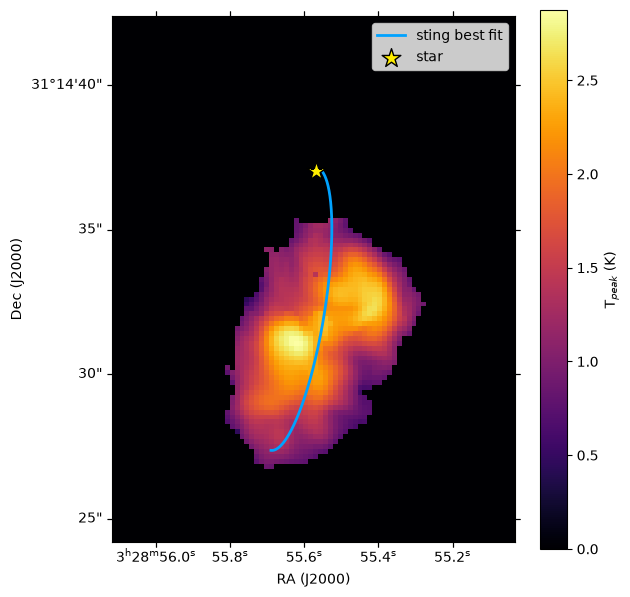

In [4]:
fig = plt.figure(figsize=(6.5, 7))
ax = fig.add_subplot(projection=wcs)

im = ax.imshow(tpeak.value, origin='lower', cmap='inferno')
fig.colorbar(im, ax=ax, label=f'T$_{{peak}}$ ({tpeak.unit})')

# world_to_pixel handles the frame conversion (the trajectory is ICRS, the cube FK5)
traj_x, traj_y = wcs.world_to_pixel(traj_sky)
ax.plot(traj_x, traj_y, color='#00A2FF', lw=2, label='sting best fit')
star_x, star_y = wcs.world_to_pixel(star_position)
ax.scatter(star_x, star_y, marker='*', s=200, color='#FFEE00', edgecolor='black', zorder=10, label='star')

# make sure RA increases to the left, whichever way the cube's RA pixel axis runs
ny, nx = tpeak.shape
ra_first, ra_last = wcs.pixel_to_world(np.array([0, nx - 1]), np.zeros(2)).ra.deg
ax.set_xlim((-0.5, nx - 0.5) if ra_first > ra_last else (nx - 0.5, -0.5))
ax.set_ylim(-0.5, ny - 0.5)
ax.coords[0].set_axislabel('RA (J2000)')
ax.coords[1].set_axislabel('Dec (J2000)')
ax.coords[0].set_major_formatter('hh:mm:ss.s')
ax.coords[1].set_major_formatter('dd:mm:ss')
ax.legend(loc='upper right')
plt.show()

## Velocity vs projected radius

The background is an intensity-weighted KDE of the cube's voxels in (projected radius, velocity), normalised to its
peak and filled between the 1, 1.5 and 2 sigma levels (as in sting's `best_fit_vel_radius.png`).

In [5]:
from astropy.stats import mad_std
from scipy.stats import gaussian_kde

# projected radius of every pixel from the star (arcsec)
ny, nx = tpeak.shape
pix_y, pix_x = np.mgrid[0:ny, 0:nx]
pix_sky = wcs.pixel_to_world(pix_x, pix_y)
pix_dra, pix_ddec = star_position.spherical_offsets_to(pix_sky.transform_to(star_position.frame))
pix_rproj = np.hypot(pix_dra.to(u.arcsec).value, pix_ddec.to(u.arcsec).value)

# voxels above the threshold: projected radius, velocity and intensity
data = cube.unmasked_data[:].value
thresh = rms_thresh * mad_std(data, ignore_nan=True)
chan, row, col = np.nonzero(np.isfinite(data) & (data > thresh))
vox_r = pix_rproj[row, col]
vox_v = cube.spectral_axis.to_value(u.km/u.s)[chan]
vox_w = data[chan, row, col]
print(f'{len(vox_r)} voxels above {thresh:.3g} {cube.unit}')

# intensity-weighted KDE on a grid, normalised to its peak
r_lim = (0.0, vox_r.max() + 0.5)
v_lim = (vox_v.min() - 0.5, vox_v.max() + 0.5)
rr, vv = np.mgrid[r_lim[0]:r_lim[1]:100j, v_lim[0]:v_lim[1]:100j]
kde = gaussian_kde(np.vstack([vox_r, vox_v]), weights=vox_w)
zz = kde(np.vstack([rr.ravel(), vv.ravel()])).reshape(rr.shape)
zz /= zz.max()
sigma_levels = np.array([1.0, 1.5, 2.0])
levels = np.append(np.exp(-0.5 * sigma_levels**2)[::-1], 1.0)

# best-fit model projected radius
traj_rproj = np.hypot(traj['ra_offset_arcsec'], traj['dec_offset_arcsec'])

# plot limits: the region inside the outermost KDE level, plus the model curve
inside = zz >= levels[0]
plot_r_lim = (0.0, max(rr[inside].max(), traj_rproj.max()) + 0.5)
plot_v_lim = (min(vv[inside].min(), traj['v_lsr_kms'].min()) - 0.5,
              max(vv[inside].max(), traj['v_lsr_kms'].max()) + 0.5)

60997 voxels above 0 K


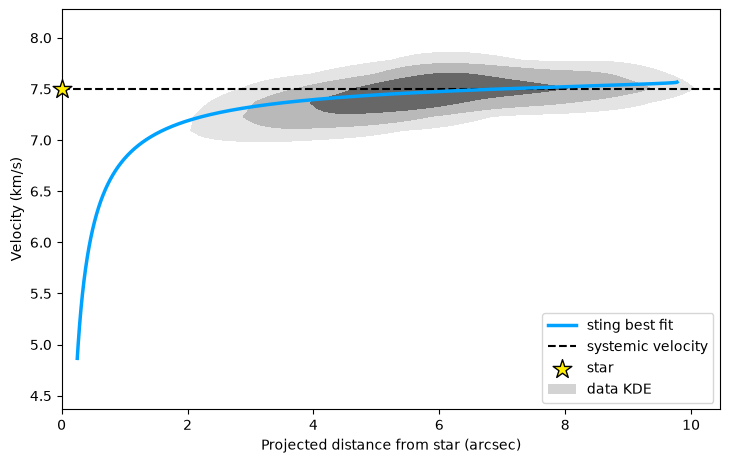

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.contourf(rr, vv, zz, levels=levels, cmap='Greys', vmin=0, vmax=1.2, zorder=1)
ax.plot(traj_rproj, traj['v_lsr_kms'], color='#00A2FF', lw=2.5, label='sting best fit', zorder=8)
if v_lsr is not None:
    ax.axhline(v_lsr, color='black', ls='--', label='systemic velocity', zorder=4)
    ax.scatter(0, v_lsr, marker='*', s=200, color='#FFEE00', edgecolor='black', zorder=10, clip_on=False, label='star')

from matplotlib.patches import Patch
handles, _ = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='lightgray', label='data KDE'))
ax.legend(handles=handles, loc='lower right')
ax.set_xlim(plot_r_lim)
ax.set_ylim(plot_v_lim)
ax.set_xlabel('Projected distance from star (arcsec)')
ax.set_ylabel('Velocity (km/s)')
plt.show()